### Agricultural Yield Dataset

In [15]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
# Load Dataset
data = pd.read_csv("agriculture_yield_dataset.csv")

**Part A: Understanding the Dataset**

Q1. Dataset Overview Load the dataset and answer the following:
    
*   How many rows and columns are present?
*   What are the names of all columns?
*   Display the first 10 records.





    
    

In [5]:

print("Rows and Columns:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nFirst 10 Records:")
print(data.head(10))

Rows and Columns:
(1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

Q2. Data Types and Missing Values

*   Check the data type of each column.
*   Identify whether any missing values are present.
*   If missing values exist, mention the affected columns.






In [6]:
print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

missing = data.columns[data.isnull().sum()>0]
print("\nColumns with Missing Values:")
print(list(missing))


Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
[]


Q3. Descriptive Statistics Generate summary statistics for all numerical features and answer:
*   Which feature has the highest mean value?
*   Which feature has the highest standard deviation?

In [7]:
stats = data.describe()

print("\nSummary Statistics:")
print(stats)

mean_feature = (stats.loc["mean"].idxmax())
std_feature = (stats.loc["std"].idxmax())

print("\nHighest Mean:",mean_feature)
print("\nHighest Std:",std_feature)


Summary Statistics:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.74000

**Part B: Exploratory Data Analysis (EDA)**

Q4. Distribution Analysis Create histograms for:

*   rainfall_mm
*   temperature_c
*   fertilizer_kg
*   yield_ton_per_hectare
    Write 2–3 observations from each histogram.





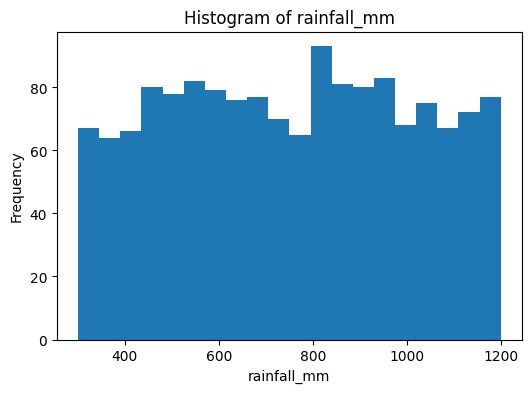

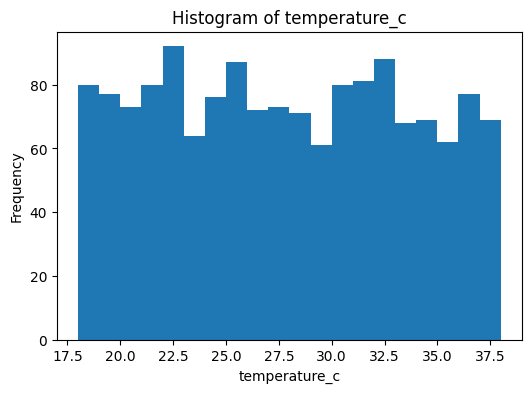

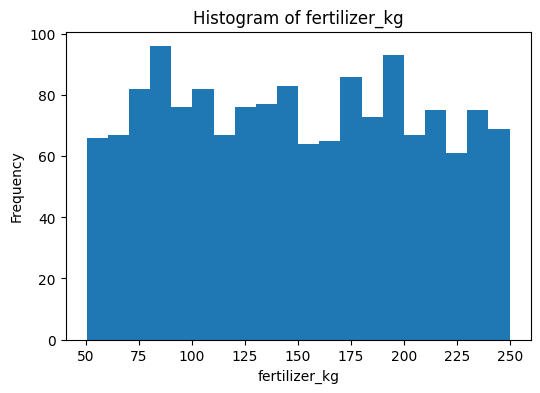

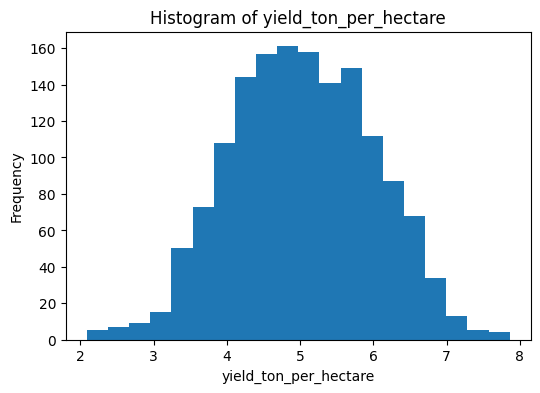

In [8]:
columns = [
"rainfall_mm",
"temperature_c",
"fertilizer_kg",
"yield_ton_per_hectare"
]

for col in columns:

    plt.figure(figsize=(6,4))
    plt.hist(data[col], bins=20)
    plt.title( f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Histogram Observations
1. rainfall_mm Histogram Observations:
*   Rainfall values are spread across a wide range.
*   Distribution appears reasonably balanced.
*   No extreme concentration at one point.

2. temperature_c Histogram Observations
*   Temperatures cluster around the middle range (~28°C).
*   Distribution looks nearly symmetric.
*   Very few extreme temperatures.

3. fertilizer_kg Histogram Observations
*   Fertilizer use varies moderately.
*   Most farms appear to use medium amounts.
*   No heavy skew.

4.  yield_ton_per_hectare Histogram Observations
*   Yield clusters near 5 tons/hectare.
*   Distribution looks approximately bell-shaped.
*   Few extreme yield values.

Q5. Crop Type Analysis  
*   Find the number of records for each crop type.
*   Create a count plot (bar chart) for crop_type.
*   Which crop appears most frequently?







Crop Count
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


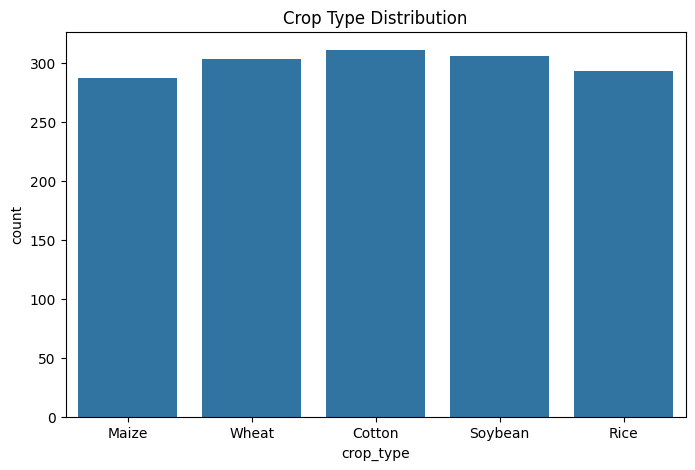


Most Frequent Crop:
Cotton


In [9]:
print("\nCrop Count")
print(data["crop_type"].value_counts())
plt.figure(figsize=(8,5))

sns.countplot(x="crop_type",data=data)
plt.title("Crop Type Distribution")
plt.show()

print("\nMost Frequent Crop:")
print(data["crop_type"].mode()[0])


Q6. Soil Type Analysis  

*   Find the frequency of each soil type.
*   Create a count plot for soil_type.
*   Which soil type is most common?






Soil Frequency
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


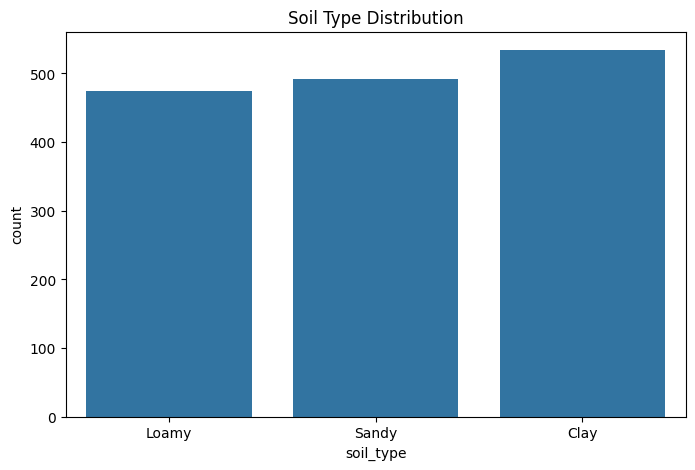


Most Common Soil:
Clay


In [10]:
print("\nSoil Frequency")
print(data["soil_type"].value_counts())
plt.figure(figsize=(8,5))

sns.countplot(x="soil_type",data=data)

plt.title("Soil Type Distribution")
plt.show()
print("\nMost Common Soil:")
print(data["soil_type"].mode()[0])


Q7. Yield Distribution Create a histogram of yield_ton_per_hectare. Answer:
*   Is the distribution approximately normal?
*   Are there any noticeable outliers?



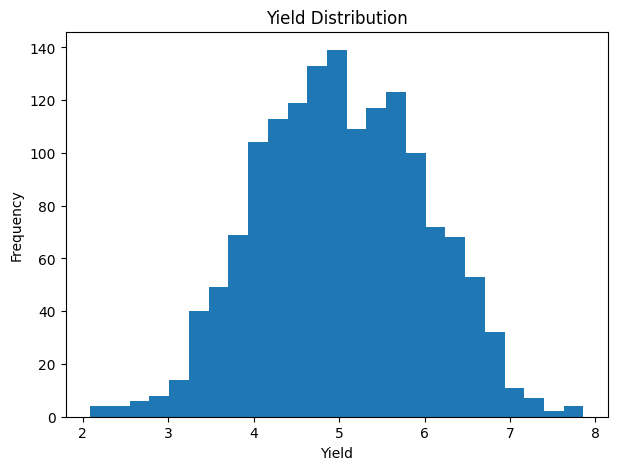

In [11]:
plt.figure(figsize=(7,5))
plt.hist(data["yield_ton_per_hectare"],bins=25)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

Is distribution approximately normal?
Yes — yield appears approximately normal.

Outliers?
No strong outliers are visible.

Q8. Scatter Plot Analysis Create scatter plots of:
1. rainfall_mm vs yield_ton_per_hectare
2. fertilizer_kg vs yield_ton_per_hectare                                    

Based on the plots:  Which feature appears to have a stronger relationship with yield?






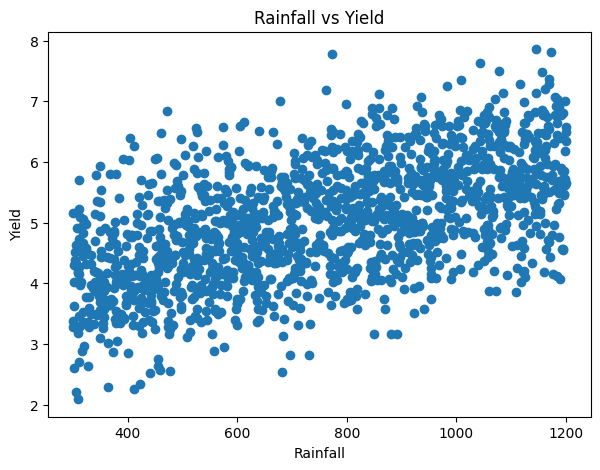

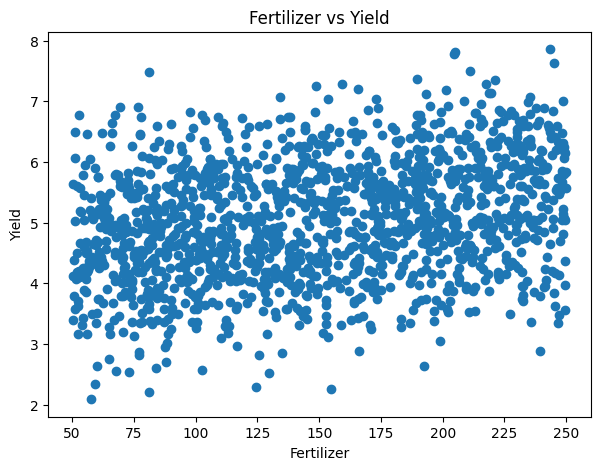

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(data["rainfall_mm"],data["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(data["fertilizer_kg"],data["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

rainfall_mm vs yield

Observation: Positive relationship,More rainfall generally increases yield.

fertilizer_kg vs yield

Observation: Positive relationship exists but weaker

Stronger Relationship with Yield

rainfall_mm


Q9. Correlation Analysis

  Generate a correlation matrix for numerical features.

  Create a heatmap.

   Identify the top three features most correlated with crop yield.


Correlation Matrix
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412    

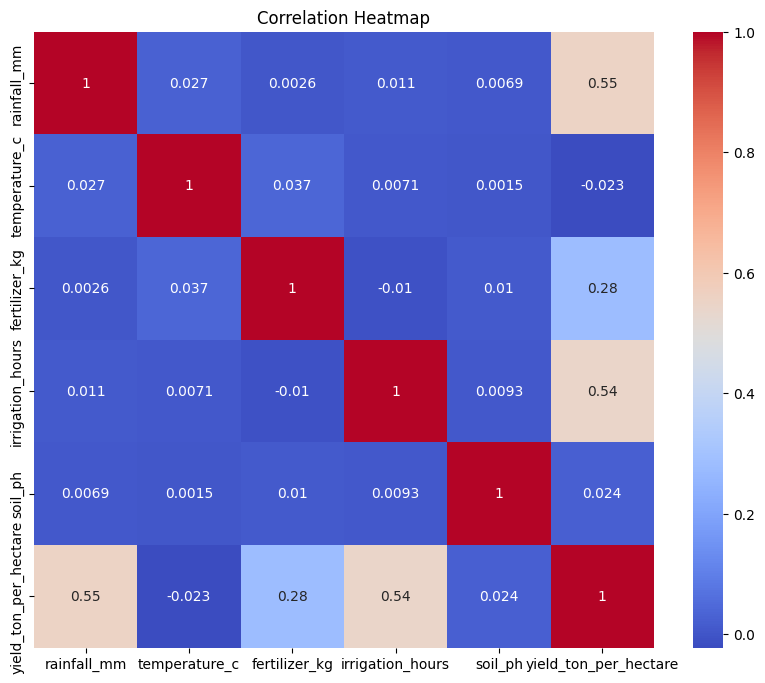


Top Correlated Features
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [13]:
numerical = data.select_dtypes(include=np.number)
corr = numerical.corr()
print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

yield_corr = (corr["yield_ton_per_hectare"].sort_values(ascending=False))
print("\nTop Correlated Features")
print(yield_corr)

Q10. Group-Based Analysis Calculate the average yield for:

 Each crop type

  Each soil type

 Which crop and soil type have the highest average yield?

In [14]:
crop_avg = (data.groupby("crop_type")["yield_ton_per_hectare"].mean())
print("\nAverage Yield by Crop")
print(crop_avg)

soil_avg = (data.groupby("soil_type")["yield_ton_per_hectare"].mean())
print("\nAverage Yield by Soil")
print(soil_avg)

print("\nHighest Yield Crop:")
print(crop_avg.idxmax())
print("\nHighest Yield Soil:")
print(soil_avg.idxmax())


Average Yield by Crop
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


**Part C: Data Preparation**

Q11. Feature Encoding

The dataset contains categorical variables.

 Identify the categorical columns.

 Convert them into numerical form using One-Hot Encoding.

  Display the first five rows of the transformed dataset.

In [16]:
print("Categorical Columns:\n")
categorical_cols = (data.select_dtypes(include="object").columns)
print(categorical_cols)

# One-Hot Encoding
encoded_data = pd.get_dummies(data,columns=categorical_cols,drop_first=True)
print("\nFirst Five Rows After Encoding:")
print(encoded_data.head())

Categorical Columns:

Index(['crop_type', 'soil_type'], dtype='object')

First Five Rows After Encoding:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False   

Q12. Feature Selection Separate:

 Input features (X)

  Target variable (y)

  Specify which column is being used as the target variable.

In [17]:
# Target Variable
target = "yield_ton_per_hectare"
print("\nTarget Variable:")
print(target)

# Features
X = encoded_data.drop(target,axis=1)
# Target
y = encoded_data[target]

print("\nInput Features Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)



Target Variable:
yield_ton_per_hectare

Input Features Shape:
(1500, 11)

Target Shape:
(1500,)


**Part D: Machine Learning**

Q13. Train-Test Split Split the dataset into:

 80% Training Data
  20% Testing Data

 Display the shape of:

  X_train

  X_test

   y_train
  
   y_test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("\nX_train Shape:")
print(X_train.shape)
print("\nX_test Shape:")
print(X_test.shape)

print("\ny_train Shape:")
print(y_train.shape)
print("\ny_test Shape:")
print(y_test.shape)


X_train Shape:
(1200, 11)

X_test Shape:
(300, 11)

y_train Shape:
(1200,)

y_test Shape:
(300,)


Q14. Linear Regression Model

 Train a Linear Regression model.

  Display the model coefficients and intercept.

   Which feature has the highest positive coefficient?

In [19]:
model = LinearRegression()
model.fit(X_train,y_train)

# Coefficients
coef = pd.DataFrame({"Feature":X.columns,"Coefficient":model.coef_})
print("\nModel Coefficients:")
print(coef)

print("\nIntercept:")
print(model.intercept_)

# Highest Positive Coefficient
highest = coef.loc[coef["Coefficient"].idxmax()]
print("\nFeature with Highest Positive Coefficient:")
print(highest)


Model Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Intercept:
1.587132027736121

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
